{'topic': '猫咪', 'poem': '## 《猫》\n\n踱过月光的斑纹，收束\n比夜更深的幽静。\n前爪按住的毛线球，\n是星子散落的虚影。\n\n忽而竖瞳里竖起，\n某种古老的刻度。\n尾尖扫过的声息，\n让瓷器屏住呼吸。\n\n跃起时，我的手掌，\n接住一团轻坠的暖意。\n它用带刺的舌舔舐，\n指缝里游动的光粒。\n\n胡须颤动，把夜，\n分成可丈量的方格。\n突然扑向空气里，\n不存在的蝶——这时才转身，\n用背影写下诘问：\n“谁把整个夜晚，\n放进我的瞳孔？”\n\n## 另一种版本：《家猫》\n\n沙发是慵懒的岛屿，\n尾巴是游动的河。\n打翻夕阳的瞬间，\n纸箱里住着云朵。\n\n罐头撬开时，彩虹\n从食盆里爬出来。\n你蹲守的每个纸团，\n都是未拆封的星系。\n\n镜子里，那个\n追逐自我倒影的魂灵，\n忽然想起很久以前，\n曾用九次生命交换，\n一个打盹的黄昏。\n\n毛茸茸的暴君啊，\n统治着柔软的国度。\n当你的毛发穿过晨光，\n整座房子就变成，\n你肚皮上的绒毛。', 'content_type': '诗'}
{'topic': '猫咪', 'joke': '一个笑话：\n\n主人对猫说：“你能不能像狗一样，我把东西扔出去，你帮我捡回来？”\n\n猫白了他一眼：“你是不是蠢？是我扔出去，你去捡回来才对。”', 'content_type': '笑话'}


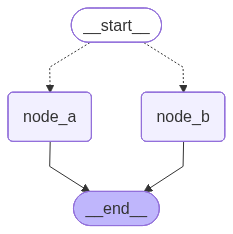

In [1]:
from typing import TypedDict,Literal
from langchain_deepseek import ChatDeepSeek
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
load_dotenv(override=True)

model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={
        "thingking":{
            "type":"disabled"
        }
    }
)

#1. 定义状态
class OverAllState(TypedDict):
    topic: str
    poem: str
    joke: str
    content_type: str

#2. 定义节点
def node_a(state: OverAllState) -> OverAllState:
    poem = model.invoke([f"写一首关于{state['topic']}主题的诗"]).content
    return {
        "poem": poem
    }

def node_b(state: OverAllState) -> OverAllState:
    joke = model.invoke([f"写一个关于{state['topic']}主题的笑话"]).content
    return {
        "joke": joke
    }

def my_route(state: OverAllState) -> Literal["node_a","node_b"]:
    if "诗" in state["content_type"]:
        return "node_a"
    else:
        return "node_b"


#3. 构建图
builder = StateGraph(state_schema=OverAllState)
builder.add_node(node_a)
builder.add_node(node_b)
builder.add_conditional_edges(START,my_route)
builder.add_edge("node_b",END)
builder.add_edge("node_a",END)

graph = builder.compile()
poem_res = graph.invoke({"topic": "猫咪","content_type":"诗"})
print(poem_res)

joke_res = graph.invoke({"topic": "猫咪","content_type":"笑话"})
print(joke_res)

from IPython.display import display
display(graph)
